# Thesis Notebook — SRQ1 (POOLED-5)

**Owner**: Enrico Manfron
**Institution**: Copenhagen Business School (MSc 2026)
**Created**: 2026-04-24

**Scope**: Pooled forecasting across 5 categories: csd, danskvand, energidrikke, rtd, totalbeer.

**Goal — answer SRQ1**: does training a single LightGBM/XGBoost on the union of
5 categories produce better/worse forecasts than 5 category-specialized
models? This notebook is the **pooled side** of that comparison.

**Inputs**: engineered feature matrices from the per-category notebooks:
- `outputs/feature_matrix_split.parquet`
- `outputs_danskvand/feature_matrix_split.parquet`
- `outputs_energidrikke/feature_matrix_split.parquet`
- `outputs_rtd/feature_matrix_split.parquet`
- `outputs_totalbeer/feature_matrix_split.parquet`

**Method**: concatenate inputs (adding a `category` column), re-fit preprocessing
pipelines on the union, run Optuna 50 trials × 2 algorithms, evaluate per category
to enable side-by-side comparison.

**Output dir**: `outputs_pooled_5/`

---

# §0 — Setup

**Why**: imports, paths, seed, list of categories to pool. Run before any other cell.

In [1]:
# §0 — Setup
import sys, json, time, io, warnings, pickle as pkl
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

PROJECT_ROOT = Path("/Users/enricomanfron/Desktop/Thesis Maniflod")
sys.path.insert(0, str(PROJECT_ROOT))

SCOPE = "pooled_5"
CATEGORIES = ['csd', 'danskvand', 'energidrikke', 'rtd', 'totalbeer']
SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = PROJECT_ROOT / "docs" / "thesis" / "analysis" / f"outputs_{SCOPE}"
FIGURE_DIR = OUTPUT_DIR / "figures"
PIPE_DIR   = OUTPUT_DIR / "pipelines"
for d in (OUTPUT_DIR, FIGURE_DIR, PIPE_DIR):
    d.mkdir(parents=True, exist_ok=True)

TRAIN_END   = pd.Timestamp("2025-02-01")
VAL_END     = pd.Timestamp("2025-08-01")
MIN_PERIODS = 30  # already applied per-category, kept for downstream filters

# Helper: input path per category (CSD uses 'outputs/', others 'outputs_<cat>/')
def category_input_path(cat: str) -> Path:
    sub = "outputs" if cat == "csd" else f"outputs_{cat}"
    return PROJECT_ROOT / "docs" / "thesis" / "analysis" / sub / "feature_matrix_split.parquet"

print(f"Scope       : {SCOPE}")
print(f"Categories  : {CATEGORIES}")
print(f"Output dir  : {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
print(f"\n[Input paths — must exist before running §1]")
for c in CATEGORIES:
    p = category_input_path(c)
    print(f"  {c:<14s} {'✓' if p.exists() else '✗ MISSING'}  {p.relative_to(PROJECT_ROOT)}")


Scope       : pooled_5
Categories  : ['csd', 'danskvand', 'energidrikke', 'rtd', 'totalbeer']
Output dir  : docs/thesis/analysis/outputs_pooled_5

[Input paths — must exist before running §1]
  csd            ✓  docs/thesis/analysis/outputs/feature_matrix_split.parquet
  danskvand      ✓  docs/thesis/analysis/outputs_danskvand/feature_matrix_split.parquet
  energidrikke   ✓  docs/thesis/analysis/outputs_energidrikke/feature_matrix_split.parquet
  rtd            ✓  docs/thesis/analysis/outputs_rtd/feature_matrix_split.parquet
  totalbeer      ✓  docs/thesis/analysis/outputs_totalbeer/feature_matrix_split.parquet


/Users/enricomanfron/Desktop/Thesis Maniflod/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### §0 — Observations + Decisions

- All 5 input parquet present? If any ✗, **run that category's notebook first**.
- Total expected rows ≈ sum of per-category feature_matrix sizes.

---

# §1 — Load per-category feature matrices + concatenate

**Why**: each per-category notebook has already done DB pull, retailer aggregation,
feature engineering, and split. We just **concatenate** the engineered frames,
adding a `category` column to identify origin. No re-engineering needed.

This means the same lag/rolling/calendar features defined per category carry over
into the pooled set — and (critically) every (brand, channel) series is contained
within a single category, so within-group operations remain valid.

In [2]:
# §1 — Load + concatenate per-category engineered matrices
parts = []
for c in CATEGORIES:
    p = category_input_path(c)
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p} — run the {c} notebook first.")
    df_c = pd.read_parquet(p)
    df_c["category"] = c
    parts.append(df_c)
    print(f"  {c:<14s} {len(df_c):>6,} rows × {len(df_c.columns):>2} cols")

df = pd.concat(parts, ignore_index=True)
df["category"] = df["category"].astype("category")

# Sort deterministically
df = df.sort_values(["category", "brand", "channel", "date"], kind="stable").reset_index(drop=True)

print(f"\n[Pooled frame]")
print(f"  Total rows           : {len(df):,}")
print(f"  Unique categories    : {df['category'].nunique()}")
print(f"  Unique brand×channel×category triples: {df.groupby(['category','brand','channel']).ngroup().nunique():,}")
print(f"\n[Per-category breakdown]")
print(df.groupby("category", observed=True).agg(
    rows=("brand", "size"),
    n_brands=("brand", "nunique"),
    n_channels=("channel", "nunique"),
).to_string())

print(f"\n[Split distribution]")
print(df.groupby("split", observed=True).size().to_string())

# Persist
df.to_parquet(OUTPUT_DIR / "feature_matrix_pooled.parquet", index=False)
print(f"\n✅ Saved: {OUTPUT_DIR.name}/feature_matrix_pooled.parquet")


  csd            24,109 rows × 31 cols
  danskvand       6,224 rows × 30 cols
  energidrikke    9,416 rows × 30 cols
  rtd             9,534 rows × 30 cols
  totalbeer      51,645 rows × 30 cols

[Pooled frame]
  Total rows           : 100,928
  Unique categories    : 5
  Unique brand×channel×category triples: 2,818

[Per-category breakdown]
               rows  n_brands  n_channels
category                                 
csd           24109        77          17
danskvand      6224        25          18
energidrikke   9416        26          18
rtd            9534        42          18
totalbeer     51645       246          18

[Split distribution]
split
test     17381
train    67991
val      15556

✅ Saved: outputs_pooled_5/feature_matrix_pooled.parquet


### §1 — Observations + Decisions

- _Total pooled rows: ..._
- _Largest category by row count: ..._
- _Class imbalance: if one category dominates (>60%), consider stratified sampling — investigate after first model run._

---

# §2 — Preprocessing pipeline (re-fit on pooled TRAIN)

**Why**: the per-category pipelines were fit on each category's TRAIN. For the pooled
model we need to **re-fit** on the union: brand+channel cardinality is much larger
(union of all categories), and `category` is a new feature that didn't exist before.

In [3]:
# §2 — Re-fit preprocessing on pooled TRAIN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

train_df = df[df["split"] == "train"]

# Feature lists — same as per-category notebooks PLUS 'category'
NUMERIC_FEATS = [
    "weighted_dist",
    "lag_1", "lag_2", "lag_3", "lag_12",
    "rolling_mean_4", "rolling_std_4", "rolling_mean_13",
    "month_sin", "month_cos", "months_since_start",
    "promo_intensity_lag_1", "unit_price_lag_1",
    "brand_mean_sales", "brand_std_sales", "brand_rank",
    "channel_mean_sales",
]
CAT_FEATS = ["brand", "channel", "category"]
TARGET = "log_sales_units"

# Sanity: drop rows where required numeric features are all-NaN
missing_cols = [c for c in NUMERIC_FEATS if c not in df.columns]
if missing_cols:
    print(f"⚠ Missing columns in pooled frame: {missing_cols}")
    NUMERIC_FEATS = [c for c in NUMERIC_FEATS if c not in missing_cols]

pipe_linear = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), NUMERIC_FEATS),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), CAT_FEATS),
], remainder="drop", verbose_feature_names_out=False)

pipe_tree = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), NUMERIC_FEATS),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT_FEATS),
], remainder="drop", verbose_feature_names_out=False)

pipe_linear.fit(train_df)
pipe_tree.fit(train_df)

X_train_lin = pipe_linear.transform(train_df)
X_train_tree= pipe_tree.transform(train_df)
print(f"pipe_linear (Ridge): {X_train_lin.shape[0]:,} × {X_train_lin.shape[1]} cols")
print(f"pipe_tree (LGB/XGB): {X_train_tree.shape[0]:,} × {X_train_tree.shape[1]} cols")

with open(PIPE_DIR / "pipe_linear.pkl", "wb") as f: pkl.dump(pipe_linear, f)
with open(PIPE_DIR / "pipe_tree.pkl",   "wb") as f: pkl.dump(pipe_tree, f)


pipe_linear (Ridge): 67,991 × 430 cols
pipe_tree (LGB/XGB): 67,991 × 20 cols


### §2 — Observations + Decisions

- _Pipe dimensionality (linear): ..._
- _Pipe dimensionality (tree): ..._

---

# §3 — Baselines (SeasonalNaive, Ridge)

**Why**: same baselines as per-category notebooks, computed on pooled VAL.

In [4]:
# §3 — Baselines
from sklearn.linear_model import RidgeCV

def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = y_true > 0
    if mask.sum() == 0: return {"mape_median": np.nan, "mape_mean": np.nan, "wape": np.nan, "rmse": np.nan}
    ape = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100
    return {
        "mape_median": float(np.median(ape)),
        "mape_mean":   float(np.mean(ape)),
        "wape":        float(np.abs(y_true - y_pred).sum() / np.abs(y_true).sum() * 100),
        "rmse":        float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
    }

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
X_val_lin   = pipe_linear.transform(val_df)
X_val_tree  = pipe_tree.transform(val_df)
y_val       = val_df["sales_units"].values
y_train_log = train_df["log_sales_units"].fillna(0).values

results = []
predictions_val = val_df[["category", "brand", "channel", "date", "sales_units"]].copy()

# SeasonalNaive
sn_raw  = val_df["lag_12"].values
brand_means = train_df.groupby("brand")["sales_units"].mean().to_dict()
sn_fallback = val_df["brand"].map(brand_means).fillna(train_df["sales_units"].mean()).values
sn_pred = np.where(np.isnan(sn_raw), sn_fallback, sn_raw)
sn_pred = np.clip(sn_pred, 0, None)
sn_metrics = compute_metrics(y_val, sn_pred)
predictions_val["SeasonalNaive"] = sn_pred
results.append({"model": "SeasonalNaive", **sn_metrics})
print(f"[SeasonalNaive] VAL: {sn_metrics}")

# Ridge
t0 = time.perf_counter()
ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0], cv=5)
ridge.fit(X_train_lin, y_train_log)
ridge_pred = np.clip(np.expm1(ridge.predict(X_val_lin)), 0, None)
ridge_metrics = compute_metrics(y_val, ridge_pred)
predictions_val["Ridge"] = ridge_pred
results.append({"model": "Ridge", **ridge_metrics})
print(f"[Ridge]         VAL: {ridge_metrics}  (alpha={ridge.alpha_}, fit={time.perf_counter()-t0:.1f}s)")


[SeasonalNaive] VAL: {'mape_median': 36.099278085937115, 'mape_mean': 1984.0771828058803, 'wape': 24.493481835461957, 'rmse': 30555.739861670638}
[Ridge]         VAL: {'mape_median': 62.395761176560896, 'mape_mean': 498.1751606525568, 'wape': 200.87672392646655, 'rmse': 1238979.01775224}  (alpha=100.0, fit=2.5s)


### §3 — Observations + Decisions

- _Pooled SeasonalNaive median MAPE: ..._
- _Pooled Ridge median MAPE: ..._
- _Compared to per-category baselines: should be similar magnitude._

---

# §4 — Optuna tuning on pooled (LightGBM + XGBoost)

**Why**: same Optuna setup as per-category. Walk-forward CV folds were assigned in
each per-category notebook and are preserved through concatenation.

In [5]:
# §4 — Optuna 50 trials × 2 algos
fold_col = train_df["cv_fold"].values

def cv_score(model_class, fixed_params, params, X_tr, y_tr, fold_col):
    fold_mapes = []
    for f in sorted(set(fold_col)):
        if f == -1: continue
        tr, va = fold_col < f, fold_col == f
        if tr.sum() < 100 or va.sum() < 5: continue
        mdl = model_class(**fixed_params, **params)
        mdl.fit(X_tr[tr], y_tr[tr])
        pred = np.clip(np.expm1(mdl.predict(X_tr[va])), 0, None)
        fold_mapes.append(compute_metrics(np.expm1(y_tr[va]), pred)["mape_median"])
    return float(np.nanmedian(fold_mapes)) if fold_mapes else float("inf")

# LightGBM
print(f"[LightGBM Optuna 50 trials on pooled]")
lgb_fixed = {"objective": "regression", "random_state": SEED, "verbose": -1}
def obj_lgb(trial):
    p = {
        "num_leaves": trial.suggest_int("num_leaves", 8, 127),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 50),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 0, 7),
    }
    return cv_score(lgb.LGBMRegressor, lgb_fixed, p, X_train_tree, y_train_log, fold_col)

study_lgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(obj_lgb, n_trials=50, show_progress_bar=True)
best_lgb_cfg, best_lgb_cv = study_lgb.best_params, study_lgb.best_value
print(f"  Best CV MAPE: {best_lgb_cv:.2f}%")

t0 = time.perf_counter()
lgb_model = lgb.LGBMRegressor(**lgb_fixed, **best_lgb_cfg)
lgb_model.fit(X_train_tree, y_train_log)
lgb_pred = np.clip(np.expm1(lgb_model.predict(X_val_tree)), 0, None)
lgb_metrics = compute_metrics(y_val, lgb_pred)
predictions_val["LightGBM_pooled"] = lgb_pred
results.append({"model": "LightGBM_pooled", "fit_time_s": time.perf_counter()-t0, **lgb_metrics})
print(f"  VAL metrics: {lgb_metrics}")
with open(PIPE_DIR / "model_lightgbm.pkl", "wb") as f: pkl.dump(lgb_model, f)

# XGBoost
print(f"\n[XGBoost Optuna 50 trials on pooled]")
xgb_fixed = {"objective": "reg:squarederror", "random_state": SEED, "tree_method": "hist", "verbosity": 0}
def obj_xgb(trial):
    p = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
    }
    return cv_score(xgb.XGBRegressor, xgb_fixed, p, X_train_tree, y_train_log, fold_col)

study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(obj_xgb, n_trials=50, show_progress_bar=True)
best_xgb_cfg, best_xgb_cv = study_xgb.best_params, study_xgb.best_value
print(f"  Best CV MAPE: {best_xgb_cv:.2f}%")

t0 = time.perf_counter()
xgb_model = xgb.XGBRegressor(**xgb_fixed, **best_xgb_cfg)
xgb_model.fit(X_train_tree, y_train_log)
xgb_pred = np.clip(np.expm1(xgb_model.predict(X_val_tree)), 0, None)
xgb_metrics = compute_metrics(y_val, xgb_pred)
predictions_val["XGBoost_pooled"] = xgb_pred
results.append({"model": "XGBoost_pooled", "fit_time_s": time.perf_counter()-t0, **xgb_metrics})
print(f"  VAL metrics: {xgb_metrics}")
with open(PIPE_DIR / "model_xgboost.pkl", "wb") as f: pkl.dump(xgb_model, f)

# Save trial logs (for thesis appendix)
study_lgb.trials_dataframe().to_csv(OUTPUT_DIR / "optuna_lgbm_trials.csv", index=False)
study_xgb.trials_dataframe().to_csv(OUTPUT_DIR / "optuna_xgboost_trials.csv", index=False)
predictions_val.to_parquet(OUTPUT_DIR / "predictions_val_all.parquet", index=False)

results_df = pd.DataFrame(results)
print(f"\n[Headline VAL metrics — POOLED]")
print(results_df[["model", "mape_median", "mape_mean", "wape", "rmse"]].to_string(index=False, float_format=lambda x: f"{x:.2f}"))
results_df.to_csv(OUTPUT_DIR / "all_models_metrics.csv", index=False)


[LightGBM Optuna 50 trials on pooled]


Best trial: 13. Best value: 21.3361: 100%|██████████| 50/50 [2:51:30<00:00, 205.81s/it]  


  Best CV MAPE: 21.34%
  VAL metrics: {'mape_median': 21.069325250317014, 'mape_mean': 39.76907994179036, 'wape': 20.043705106613398, 'rmse': 36269.742598100354}

[XGBoost Optuna 50 trials on pooled]


Best trial: 14. Best value: 21.7692: 100%|██████████| 50/50 [15:49<00:00, 18.99s/it]


  Best CV MAPE: 21.77%
  VAL metrics: {'mape_median': 21.157833001730282, 'mape_mean': 41.828317049004475, 'wape': 20.10462214534849, 'rmse': 35655.213305646066}

[Headline VAL metrics — POOLED]
          model  mape_median  mape_mean   wape       rmse
  SeasonalNaive        36.10    1984.08  24.49   30555.74
          Ridge        62.40     498.18 200.88 1238979.02
LightGBM_pooled        21.07      39.77  20.04   36269.74
 XGBoost_pooled        21.16      41.83  20.10   35655.21


### §4 — Observations + Decisions

- _Pooled best LGB CV MAPE: ..._
- _Pooled best XGB CV MAPE: ..._

---

# §5 — Per-category & per-channel breakdown — **THE SRQ1 ANSWER**

**Why**: this is the headline analysis. Compare pooled vs specialized per-brand MAPE
**within each category**. If pooled wins, knowledge transfers across categories.
If specialized wins, category patterns are too distinct to share.

This is the table that goes directly into Chapter 6 of the thesis.

In [6]:
# §5 — Per-category breakdown
def per_brand_mape(df_eval, pred_col):
    mapes = []
    for b in df_eval["brand"].unique():
        sub = df_eval[df_eval["brand"] == b]
        m = compute_metrics(sub["sales_units"].values, sub[pred_col].values)["mape_median"]
        if not np.isnan(m): mapes.append(m)
    return float(np.median(mapes)) if mapes else float("nan")

print(f"=" * 75)
print(f"PER-CATEGORY PERFORMANCE OF POOLED MODEL — vs specialized (when available)")
print(f"=" * 75)
print(f"{'category':<14s}{'rows':>7s}{'POOL_LGB':>11s}{'POOL_XGB':>11s}{'SPEC_LGB*':>12s}{'SPEC_XGB*':>12s}")
print("-" * 75)

for cat in CATEGORIES:
    sub = predictions_val[predictions_val["category"] == cat]
    if len(sub) == 0:
        print(f"  {cat:<12s}  no rows")
        continue
    pool_lgb = per_brand_mape(sub, "LightGBM_pooled")
    pool_xgb = per_brand_mape(sub, "XGBoost_pooled")
    # Try to load the specialized notebook's metrics for direct comparison
    sub_path = PROJECT_ROOT / "docs" / "thesis" / "analysis" / ("outputs" if cat == "csd" else f"outputs_{cat}") / "all_models_metrics.csv"
    if sub_path.exists():
        spec_df = pd.read_csv(sub_path)
        spec_lgb = spec_df[spec_df["model"].str.contains("LightGBM", case=False)]["mape_median"].iloc[0] if (spec_df["model"].str.contains("LightGBM", case=False)).any() else float("nan")
        spec_xgb = spec_df[spec_df["model"].str.contains("XGBoost", case=False)]["mape_median"].iloc[0] if (spec_df["model"].str.contains("XGBoost", case=False)).any() else float("nan")
    else:
        spec_lgb = spec_xgb = float("nan")
    print(f"  {cat:<12s}{len(sub):>7d}{pool_lgb:>10.2f}%{pool_xgb:>10.2f}%{spec_lgb:>11.2f}%{spec_xgb:>11.2f}%")

print(f"\n  * SPEC values are PER-CATEGORY notebook headline (raw VAL median MAPE, not per-brand)")
print(f"  ** Negative delta (POOL < SPEC) = pooling helps for that category")

# Headline overall pooled metric
print(f"\n[Overall pooled per-brand median MAPE — across all categories]")
for m in ["SeasonalNaive", "Ridge", "LightGBM_pooled", "XGBoost_pooled"]:
    print(f"  {m:<18s} {per_brand_mape(predictions_val, m):6.2f}%")


PER-CATEGORY PERFORMANCE OF POOLED MODEL — vs specialized (when available)
category         rows   POOL_LGB   POOL_XGB   SPEC_LGB*   SPEC_XGB*
---------------------------------------------------------------------------
  csd            3498     26.47%     27.16%      21.26%      21.30%
  danskvand      1013     21.21%     21.74%      17.18%      16.69%
  energidrikke   1471     23.70%     28.77%      18.75%      17.70%
  rtd            1566     28.11%     25.61%      24.18%      24.72%
  totalbeer      8008     26.02%     26.33%      21.12%      21.06%

  * SPEC values are PER-CATEGORY notebook headline (raw VAL median MAPE, not per-brand)
  ** Negative delta (POOL < SPEC) = pooling helps for that category

[Overall pooled per-brand median MAPE — across all categories]
  SeasonalNaive       46.17%
  Ridge               63.56%
  LightGBM_pooled     26.02%
  XGBoost_pooled      26.21%


### §5 — Observations + Decisions

**Headline analysis**:
- Did pooling help on any category? _List categories where pool < spec_
- Did pooling hurt on any category? _List categories where pool > spec_
- Average delta pool vs spec: _..._

**Interpretation hints**:
- If pooled wins on ALL categories → strong evidence that knowledge transfers (thesis story: "cross-category learning improves accuracy")
- If specialized wins on most → strong evidence categories are independent (thesis story: "category patterns are distinct enough that pooling adds noise")
- If mixed → nuanced story (which categories benefit, why?)

---

# §6 — SHAP feature importance + final figures

**Why**: SHAP on the pooled LightGBM. Critical question: is `category` itself one of
the top features? If yes, the model is using category as a proxy → consistent with
"specialized wins". If no, the model treats all categories alike → consistent with
"pooled wins".

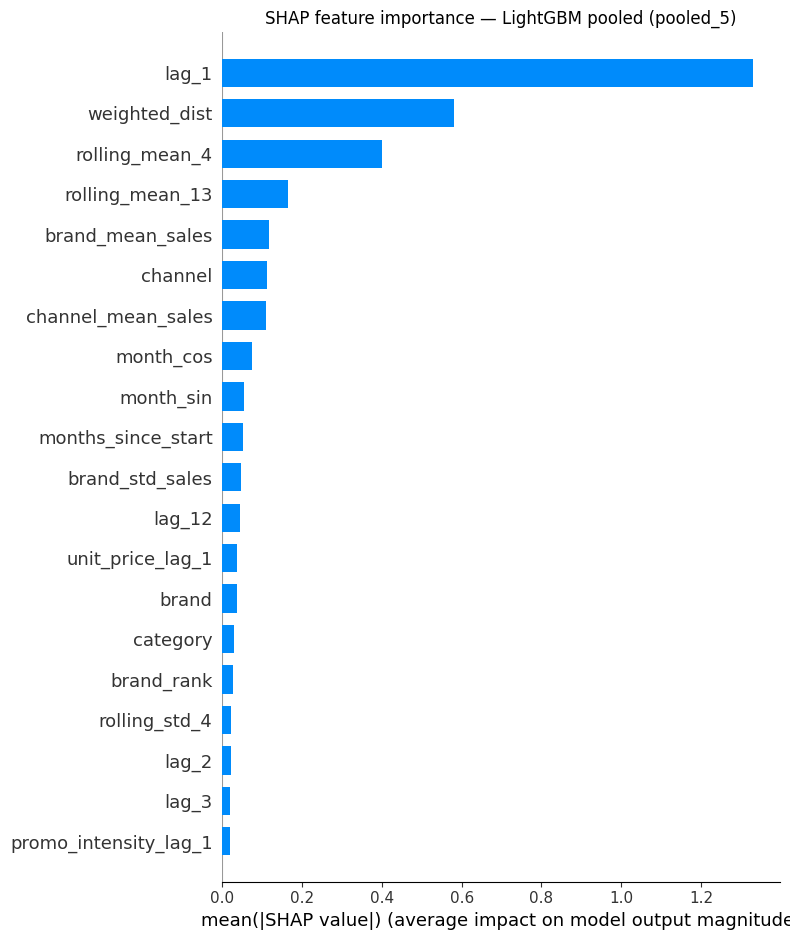

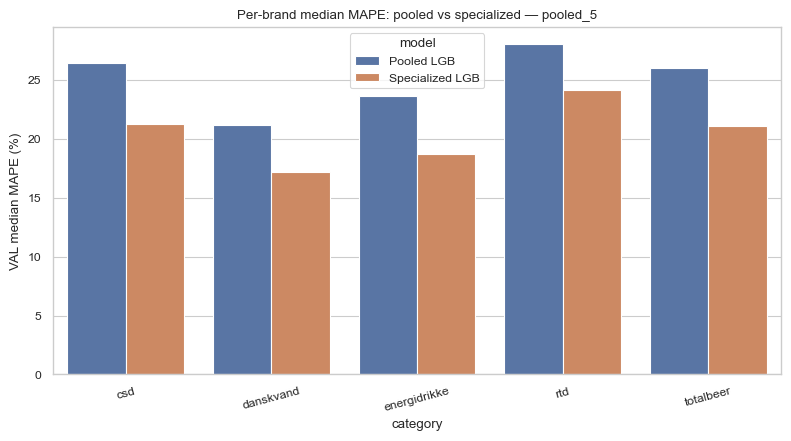


✅ Figures saved to docs/thesis/analysis/outputs_pooled_5/figures/

✅ Notebook complete. Pooled artefacts saved to docs/thesis/analysis/outputs_pooled_5/


In [7]:
# §6 — SHAP + figures
import shap

sample_n = min(2000, len(val_df))
sample = val_df.sample(sample_n, random_state=SEED).reset_index(drop=True)
X_sample = pipe_tree.transform(sample)
feature_names = NUMERIC_FEATS + CAT_FEATS

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title(f"SHAP feature importance — LightGBM pooled ({SCOPE})", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_lightgbm.png", dpi=150, bbox_inches="tight")
plt.show()

# Headline figure: per-category MAPE comparison (pool vs spec)
sns.set_theme(style="whitegrid", context="paper")
rows = []
for cat in CATEGORIES:
    sub = predictions_val[predictions_val["category"] == cat]
    if len(sub) == 0: continue
    pool_lgb = per_brand_mape(sub, "LightGBM_pooled")
    sub_path = PROJECT_ROOT / "docs" / "thesis" / "analysis" / ("outputs" if cat == "csd" else f"outputs_{cat}") / "all_models_metrics.csv"
    if sub_path.exists():
        spec_df = pd.read_csv(sub_path)
        spec_lgb = spec_df[spec_df["model"].str.contains("LightGBM", case=False)]["mape_median"].iloc[0]
    else:
        spec_lgb = float("nan")
    rows.append({"category": cat, "Pooled LGB": pool_lgb, "Specialized LGB": spec_lgb})

cmp_df = pd.DataFrame(rows).set_index("category").reset_index()
cmp_long = cmp_df.melt(id_vars="category", var_name="model", value_name="mape")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=cmp_long, x="category", y="mape", hue="model", ax=ax)
ax.set_title(f"Per-brand median MAPE: pooled vs specialized — {SCOPE}")
ax.set_ylabel("VAL median MAPE (%)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig_pool_vs_spec.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Figures saved to {FIGURE_DIR.relative_to(PROJECT_ROOT)}/")
print(f"\n✅ Notebook complete. Pooled artefacts saved to {OUTPUT_DIR.relative_to(PROJECT_ROOT)}/")


### §6 — Observations + Decisions

- _Top 3 SHAP features for pooled LGB: ..._
- _Is `category` one of the top features? Yes/No interpretation: ..._

---

## End of pooled_5 notebook

Key outputs:
- `outputs_pooled_5/all_models_metrics.csv` → headline pooled metrics
- `outputs_pooled_5/predictions_val_all.parquet` → all model predictions on VAL
- `outputs_pooled_5/figures/fig_pool_vs_spec.png` → headline figure for thesis
- `outputs_pooled_5/pipelines/model_*.pkl` → trained pooled models